In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [13]:
df = pd.read_csv("House_Data.csv")

print(df.head())
print(df.columns)

              area_type   availability                  location       size  \
0  Super built-up  Area         19-Dec  Electronic City Phase II      2 BHK   
1            Plot  Area  Ready To Move          Chikka Tirupathi  4 Bedroom   
2        Built-up  Area  Ready To Move               Uttarahalli      3 BHK   
3  Super built-up  Area  Ready To Move        Lingadheeranahalli      3 BHK   
4  Super built-up  Area  Ready To Move                  Kothanur      2 BHK   

   society total_sqft  bath  balcony   price  
0  Coomee        1056   2.0      1.0   39.07  
1  Theanmp       2600   5.0      3.0  120.00  
2      NaN       1440   2.0      3.0   62.00  
3  Soiewre       1521   3.0      1.0   95.00  
4      NaN       1200   2.0      1.0   51.00  
Index(['area_type', 'availability', 'location', 'size', 'society',
       'total_sqft', 'bath', 'balcony', 'price'],
      dtype='object')


In [14]:
# Drop unnecessary columns
df = df.drop(['area_type', 'availability', 'society', 'balcony'], axis=1)

# Drop missing values
df = df.dropna()

# Convert 'size' (e.g., "2 BHK") → integer
df['bhk'] = df['size'].apply(lambda x: int(x.split(' ')[0]))

# Convert total_sqft to numeric
def convert_sqft(x):
    try:
        if '-' in x:
            a, b = x.split('-')
            return (float(a) + float(b)) / 2
        return float(x)
    except:
        return None

df['total_sqft'] = df['total_sqft'].apply(convert_sqft)

df = df.dropna()

In [15]:
# One-hot encoding for location
df = pd.get_dummies(df, columns=['location'])

# Define X and y
X = df.drop(['price', 'size'], axis=1)
y = df['price']

In [16]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Linear Regression MSE:", mean_squared_error(y_test, y_pred_lr))

Linear Regression MSE: 7458.024359347526


In [17]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor()
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Decision Tree MSE:", mean_squared_error(y_test, y_pred_dt))

Decision Tree MSE: 6875.858193504657


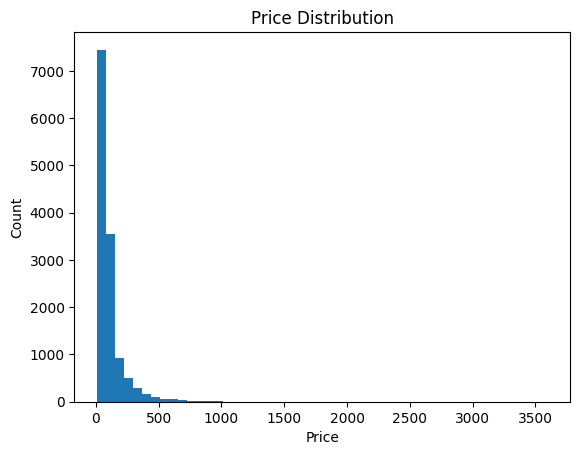

In [18]:
plt.hist(df['price'], bins=50)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

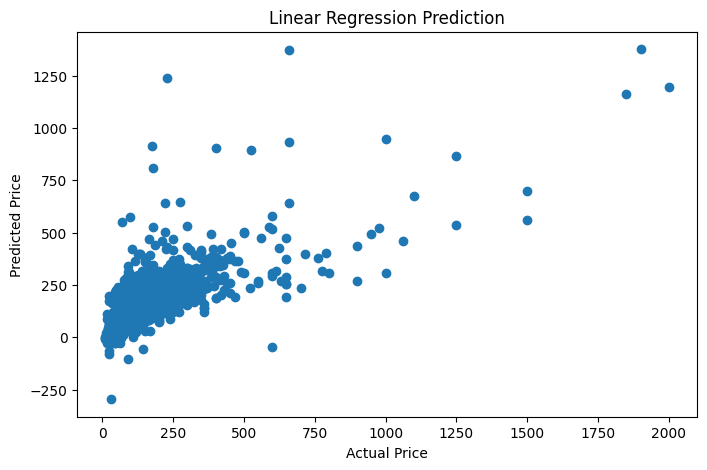

In [19]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred_lr)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Linear Regression Prediction")
plt.show()